# BTC/USDT — Simple Daily DCA Backtest

The most basic DCA strategy: **buy a fixed dollar amount of BTC every single day**, no conditions, no timing, no indicators.

| Parameter | Value |
|-----------|-------|
| Frequency | Every trading day |
| Signal | None — always buy |
| Exit | None (hold forever) |
| Fee | 0.1% per trade |

**Compared against:** BTC lump-sum buy & hold on day 1.

**Metrics:** Sharpe Ratio · Sortino Ratio · Maximum Drawdown · CAGR

In [1]:
# pip install yfinance requests pandas numpy matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import yfinance as yf
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
print('Libraries loaded.')

Libraries loaded.


In [2]:
def fetch_btc_price(start='2018-02-01', end=None):
    if end is None:
        end = datetime.today().strftime('%Y-%m-%d')
    raw = yf.Ticker('BTC-USD').history(start=start, end=end, interval='1d')
    raw = raw[['Open', 'High', 'Low', 'Close', 'Volume']].reset_index()
    raw.rename(columns={
        'Date': 'date', 'Open': 'open', 'High': 'high',
        'Low': 'low', 'Close': 'close', 'Volume': 'volume'
    }, inplace=True)
    raw['date'] = raw['date'].dt.tz_localize(None).dt.normalize()
    return raw.sort_values('date').reset_index(drop=True)

data = fetch_btc_price(start='2018-02-01')
print(f'BTC/USD daily data: {len(data)} rows  |  {data.date.min().date()} → {data.date.max().date()}')
data.tail(3)

BTC/USD daily data: 3010 rows  |  2018-02-01 → 2026-04-29


,date,open,high,low,close,volume
3007,2026-04-27,78661.015625,79488.171875,76481.343750,77366.625000,38135631927
3008,2026-04-28,77368.117188,77483.867188,75673.601562,76350.671875,32056900880
3009,2026-04-29,76350.687500,77884.968750,74958.570312,75776.132812,41460907886


In [3]:
PARAMS = {
    # Total capital pool (USDT). DCA draws from this until it runs out.
    'initial_capital': 10_000,

    # Fixed amount to invest every single day.
    'daily_investment': 10,        # $10/day  →  $10k lasts ~1,000 days (~2.7 years)

    # Exchange fee per trade.
    'fee_rate': 0.001,             # 0.1% (Binance taker)
}

n_days = PARAMS['initial_capital'] / PARAMS['daily_investment']
print(f'Daily investment:  ${PARAMS["daily_investment"]}/day')
print(f'Capital pool:      ${PARAMS["initial_capital"]:,.0f}')
print(f'DCA runs for:      {n_days:.0f} days ({n_days/365:.1f} years) until cash depleted')

Daily investment:  $10/day
Capital pool:      $10,000
DCA runs for:      1000 days (2.7 years) until cash depleted


In [4]:
def run_simple_dca(data, params):
    cash = float(params['initial_capital'])
    btc_held = 0.0
    fee = params['fee_rate']
    daily = params['daily_investment']
    rows = []

    for _, row in data.iterrows():
        price = row['close']
        action = 'HOLD'
        trade_usdt = 0.0
        trade_btc = 0.0

        if cash >= daily:
            btc_bought = daily * (1 - fee) / price
            cash -= daily
            btc_held += btc_bought
            action = 'BUY'
            trade_usdt = daily
            trade_btc = btc_bought

        rows.append({
            'date':            row['date'],
            'price':           price,
            'cash':            cash,
            'btc_held':        btc_held,
            'btc_value':       btc_held * price,
            'portfolio_value': cash + btc_held * price,
            'action':          action,
            'trade_usdt':      trade_usdt,
            'trade_btc':       trade_btc,
        })

    return pd.DataFrame(rows)

results = run_simple_dca(data, PARAMS)

buy_days = (results['action'] == 'BUY').sum()
print(f'Backtest complete: {len(results)} days  |  {buy_days} BUY days  |  {len(results)-buy_days} HOLD days (cash depleted)')
results[['date', 'price', 'cash', 'btc_held', 'portfolio_value', 'action']].tail(5)

Backtest complete: 3010 days  |  1000 BUY days  |  2010 HOLD days (cash depleted)


,date,price,cash,btc_held,portfolio_value,action
3005,2026-04-25,77612.015625,0.0,1.416647,109948.809761,HOLD
3006,2026-04-26,78657.539062,0.0,1.416647,111429.947141,HOLD
3007,2026-04-27,77366.625000,0.0,1.416647,109601.177929,HOLD
3008,2026-04-28,76350.671875,0.0,1.416647,108161.931236,HOLD
3009,2026-04-29,75776.132812,0.0,1.416647,107348.012339,HOLD


In [5]:
def compute_metrics(results, params, risk_free_rate=0.04):
    pv = results['portfolio_value']
    initial = params['initial_capital']
    final = pv.iloc[-1]
    daily_ret = pv.pct_change().dropna()

    n_years = len(results) / 365.25
    rf_daily = (1 + risk_free_rate) ** (1 / 365.25) - 1
    excess = daily_ret - rf_daily

    sharpe = (excess.mean() / daily_ret.std()) * np.sqrt(365.25)

    downside = daily_ret[daily_ret < rf_daily]
    sortino = (excess.mean() / downside.std()) * np.sqrt(365.25) if len(downside) > 1 else np.nan

    rolling_max = pv.cummax()
    drawdown = (pv - rolling_max) / rolling_max
    max_dd = drawdown.min()

    in_dd = drawdown < 0
    groups = (in_dd != in_dd.shift()).cumsum()
    max_dd_days = in_dd.groupby(groups).sum().max()

    cagr = (final / initial) ** (1 / n_years) - 1
    total_ret = (final - initial) / initial

    # BTC buy & hold: invest full capital on day 1
    bh_btc = initial * (1 - params['fee_rate']) / results['price'].iloc[0]
    bh_final = bh_btc * results['price'].iloc[-1]
    bh_ret = (bh_final - initial) / initial

    # Average buy price for DCA
    total_btc = results['btc_held'].iloc[-1]
    total_invested = results['trade_usdt'].sum()
    avg_buy_price = total_invested / total_btc if total_btc > 0 else 0

    metrics = pd.DataFrame({
        'Metric': [
            'Initial Capital', 'Final Portfolio Value',
            'Total Return', 'CAGR',
            'Sharpe Ratio', 'Sortino Ratio',
            'Max Drawdown', 'Max DD Duration (days)',
            'Avg DCA Buy Price', 'Total BTC Accumulated',
            'BTC Buy & Hold Return',
        ],
        'Value': [
            f'${initial:,.0f}', f'${final:,.2f}',
            f'{total_ret:.2%}', f'{cagr:.2%}',
            f'{sharpe:.4f}', f'{sortino:.4f}',
            f'{max_dd:.2%}', int(max_dd_days),
            f'${avg_buy_price:,.2f}', f'{total_btc:.8f} BTC',
            f'{bh_ret:.2%}',
        ]
    })
    return metrics, drawdown

metrics_df, drawdown_series = compute_metrics(results, PARAMS)
metrics_df

,Metric,Value
0,Initial Capital,"$10,000"
1,Final Portfolio Value,"$107,348.01"
2,Total Return,973.48%
3,CAGR,33.38%
4,Sharpe Ratio,0.7343
5,Sortino Ratio,0.9731
6,Max Drawdown,-76.63%
7,Max DD Duration (days),846
8,Avg DCA Buy Price,"$7,058.92"
9,Total BTC Accumulated,1.41664675 BTC


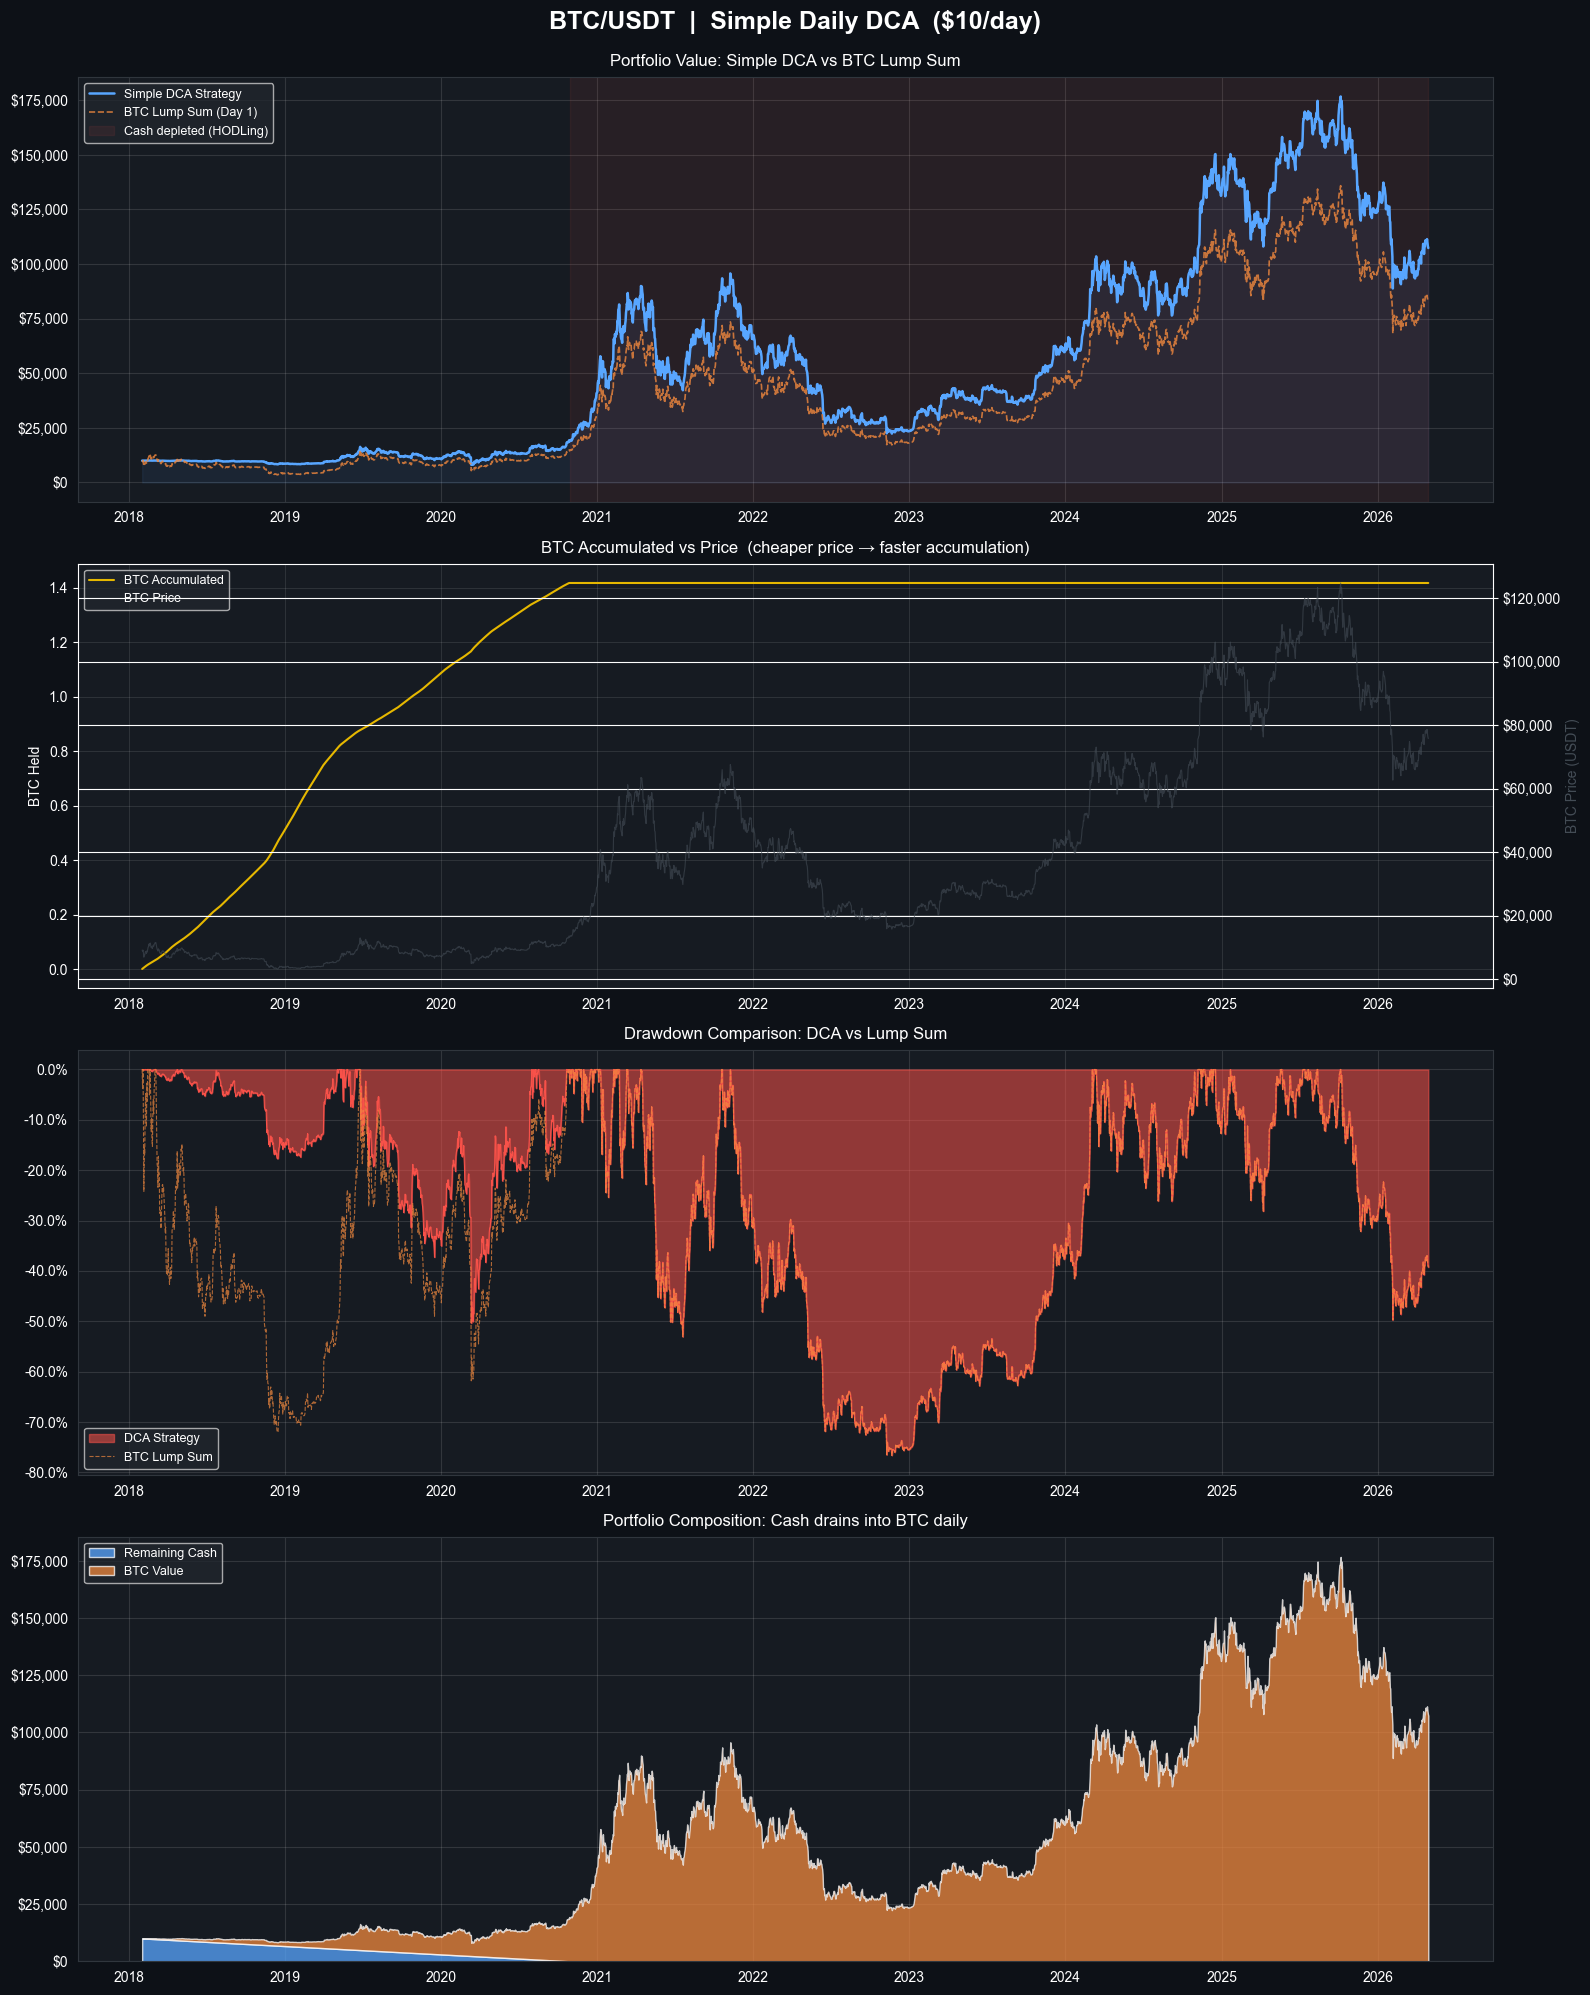

In [6]:
# Buy & Hold curve — full capital invested on day 1
bh_btc = PARAMS['initial_capital'] * (1 - PARAMS['fee_rate']) / results['price'].iloc[0]
bh_curve = bh_btc * results['price']

fig, axes = plt.subplots(4, 1, figsize=(16, 20), facecolor='#0d1117')
fig.suptitle(f'BTC/USDT  |  Simple Daily DCA  (${PARAMS["daily_investment"]}/day)',
             fontsize=18, color='white', fontweight='bold', y=0.995)

# ── Panel 1: Portfolio value ────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor('#161b22')
ax.plot(results['date'], results['portfolio_value'],
        color='#58a6ff', lw=1.8, label='Simple DCA Strategy')
ax.plot(results['date'], bh_curve,
        color='#f0883e', lw=1.2, ls='--', alpha=0.8, label='BTC Lump Sum (Day 1)')
ax.fill_between(results['date'], results['portfolio_value'],
                alpha=0.08, color='#58a6ff')

# Shade period where cash is exhausted (no more buying)
depleted = results[results['action'] == 'HOLD']
if len(depleted) > 0:
    ax.axvspan(depleted['date'].iloc[0], depleted['date'].iloc[-1],
               alpha=0.08, color='#f85149', label='Cash depleted (HODLing)')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Portfolio Value: Simple DCA vs BTC Lump Sum', color='white', pad=8)
ax.legend(facecolor='#21262d', labelcolor='white', fontsize=9)
ax.grid(alpha=0.12)

# ── Panel 2: BTC accumulated over time ─────────────────────────────────────
ax = axes[1]
ax.set_facecolor('#161b22')
ax2r = ax.twinx()
ax.plot(results['date'], results['btc_held'], color='#e6b800', lw=1.5, label='BTC Accumulated')
ax2r.plot(results['date'], results['price'], color='#444d56', lw=0.8, alpha=0.6, label='BTC Price')
ax.set_ylabel('BTC Held', color='#e6b800')
ax.tick_params(colors='white')
ax2r.set_ylabel('BTC Price (USDT)', color='#444d56')
ax2r.tick_params(colors='white')
ax2r.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('BTC Accumulated vs Price  (cheaper price → faster accumulation)', color='white', pad=8)
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2r.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, facecolor='#21262d', labelcolor='white', fontsize=9)
ax.grid(alpha=0.10)

# ── Panel 3: Drawdown ───────────────────────────────────────────────────────
ax = axes[2]
ax.set_facecolor('#161b22')
# DCA drawdown
ax.fill_between(results['date'], drawdown_series * 100, 0,
                color='#f85149', alpha=0.55, label='DCA Strategy')
ax.plot(results['date'], drawdown_series * 100, color='#f85149', lw=0.8)
# B&H drawdown
bh_pv = bh_curve
bh_dd = (bh_pv - bh_pv.cummax()) / bh_pv.cummax() * 100
ax.plot(results['date'], bh_dd, color='#f0883e', lw=0.8, ls='--', alpha=0.7, label='BTC Lump Sum')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax.set_title('Drawdown Comparison: DCA vs Lump Sum', color='white', pad=8)
ax.legend(facecolor='#21262d', labelcolor='white', fontsize=9)
ax.grid(alpha=0.12)

# ── Panel 4: Cash vs BTC value over time ───────────────────────────────────
ax = axes[3]
ax.set_facecolor('#161b22')
ax.stackplot(results['date'],
             [results['cash'], results['btc_value']],
             labels=['Remaining Cash', 'BTC Value'],
             colors=['#58a6ff', '#f0883e'], alpha=0.75)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Portfolio Composition: Cash drains into BTC daily', color='white', pad=8)
ax.legend(facecolor='#21262d', labelcolor='white', fontsize=9, loc='upper left')
ax.grid(alpha=0.12)

for ax in axes:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    for spine in ax.spines.values():
        spine.set_color('#30363d')

plt.tight_layout()
plt.savefig('simple_dca_backtest.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

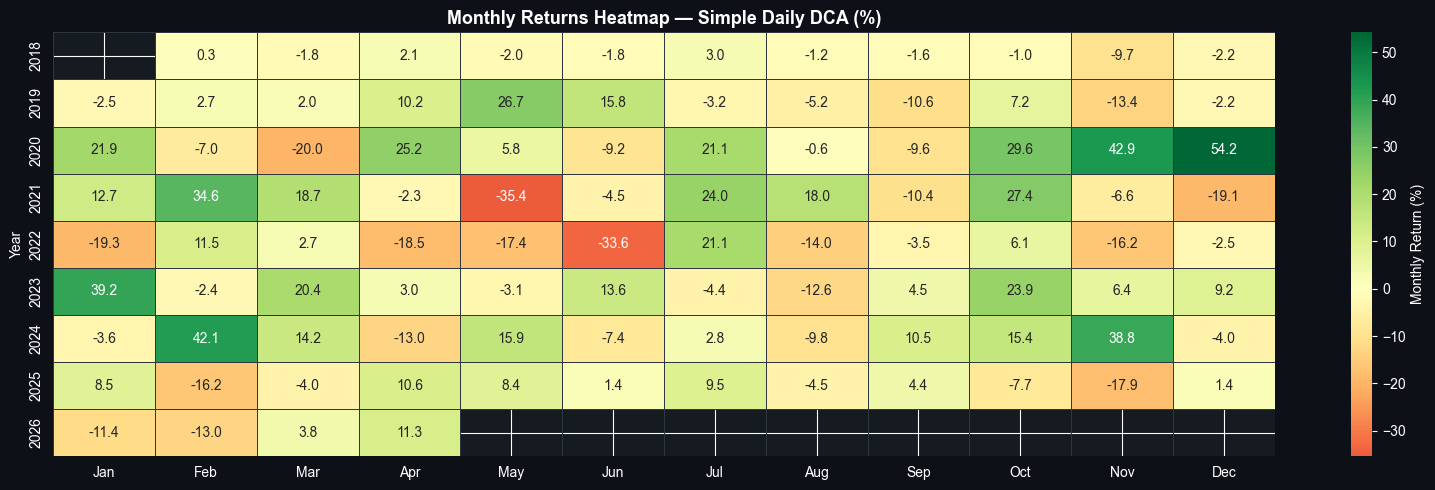

In [7]:
results['year']  = results['date'].dt.year
results['month'] = results['date'].dt.month

monthly = results.groupby(['year', 'month']).agg(
    pv_start=('portfolio_value', 'first'),
    pv_end  =('portfolio_value', 'last')
).reset_index()
monthly['ret'] = (monthly['pv_end'] - monthly['pv_start']) / monthly['pv_start'] * 100

pivot = monthly.pivot(index='year', columns='month', values='ret')
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
pivot.columns = [month_labels[m - 1] for m in pivot.columns]

fig, ax = plt.subplots(figsize=(16, 5), facecolor='#0d1117')
ax.set_facecolor('#161b22')
sns.heatmap(
    pivot, annot=True, fmt='.1f', center=0,
    cmap='RdYlGn', ax=ax,
    linewidths=0.5, linecolor='#30363d',
    cbar_kws={'label': 'Monthly Return (%)'}
)
ax.set_title('Monthly Returns Heatmap — Simple Daily DCA (%)',
             color='white', fontsize=13, fontweight='bold')
ax.tick_params(colors='white')
ax.set_xlabel('', color='white')
ax.set_ylabel('Year', color='white')
plt.tight_layout()
plt.savefig('simple_dca_monthly.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

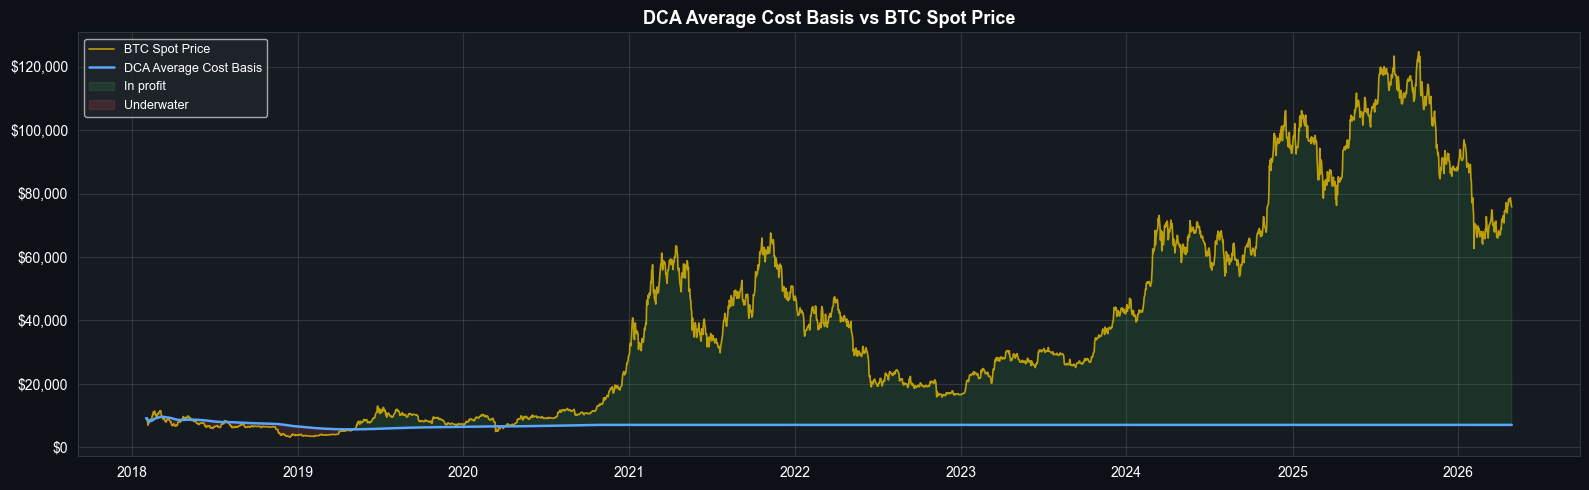

In [8]:
# Average cost basis over time vs BTC spot price
cumulative_invested = results['trade_usdt'].cumsum()
avg_cost_basis = cumulative_invested / results['btc_held'].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(16, 5), facecolor='#0d1117')
ax.set_facecolor('#161b22')
ax.plot(results['date'], results['price'],
        color='#e6b800', lw=1.2, alpha=0.8, label='BTC Spot Price')
ax.plot(results['date'], avg_cost_basis,
        color='#58a6ff', lw=1.8, label='DCA Average Cost Basis')
ax.fill_between(
    results['date'],
    results['price'],
    avg_cost_basis,
    where=(results['price'] >= avg_cost_basis),
    alpha=0.15, color='#3fb950', label='In profit'
)
ax.fill_between(
    results['date'],
    results['price'],
    avg_cost_basis,
    where=(results['price'] < avg_cost_basis),
    alpha=0.15, color='#f85149', label='Underwater'
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('DCA Average Cost Basis vs BTC Spot Price', color='white', fontsize=13, fontweight='bold')
ax.tick_params(colors='white')
ax.legend(facecolor='#21262d', labelcolor='white', fontsize=9)
ax.grid(alpha=0.12)
for spine in ax.spines.values():
    spine.set_color('#30363d')
plt.tight_layout()
plt.savefig('simple_dca_cost_basis.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

In [9]:
print('=' * 50)
print('      SIMPLE DCA — BACKTEST SUMMARY')
print('=' * 50)
for _, row in metrics_df.iterrows():
    print(f'  {row["Metric"]:<28}  {row["Value"]}')
print('=' * 50)
print(f'  Period: {results.date.min().date()} → {results.date.max().date()}')
print(f'  Daily buy:           ${PARAMS["daily_investment"]:.0f} USDT/day')
print(f'  Active DCA days:     {(results["action"]=="BUY").sum()}')
print(f'  Total cost deployed: ${results["trade_usdt"].sum():,.2f}')
print(f'  Remaining cash:      ${results["cash"].iloc[-1]:,.2f}')
print('=' * 50)

      SIMPLE DCA — BACKTEST SUMMARY
  Initial Capital               $10,000
  Final Portfolio Value         $107,348.01
  Total Return                  973.48%
  CAGR                          33.38%
  Sharpe Ratio                  0.7343
  Sortino Ratio                 0.9731
  Max Drawdown                  -76.63%
  Max DD Duration (days)        846
  Avg DCA Buy Price             $7,058.92
  Total BTC Accumulated         1.41664675 BTC
  BTC Buy & Hold Return         725.47%
  Period: 2018-02-01 → 2026-04-29
  Daily buy:           $10 USDT/day
  Active DCA days:     1000
  Total cost deployed: $10,000.00
  Remaining cash:      $0.00
